IMPORT LIBRARIES

In [2]:
# basic libraries
import pandas as pd
import numpy as np

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# save/load
import pickle

In [3]:
# load raw dataset
df = pd.read_csv('ml_features.csv')

print("Shape:", df.shape)
print(df.head())

Shape: (1468, 11)
   CustomerID  Recency  Frequency  Monetary  Coupon_Ratio  Tenure_Months  \
0       12346      108          1    180.99      1.000000             31   
1       12347       60         31  14500.04      0.333333             20   
2       12348       74          8   1639.27      0.478261             39   
3       12350       18         11   1487.95      0.352941             25   
4       12356      108         13   2079.96      0.305556             31   

   Avg_Order_Value  Purchase_Interval  Orders_last_30d  Spend_last_30d  \
0       180.990000         943.640000              0.0            0.00   
1       467.743226          19.638710              0.0            0.00   
2       204.908750         148.395000              0.0            0.00   
3       135.268182          69.181818             11.0         1487.95   
4       159.996923          72.587692              0.0            0.00   

   Active_30d  
0           0  
1           0  
2           0  
3           1  


LABEL ENGINEERING

In [4]:
# create churn label
def create_churn_label(df, recency_threshold=90):
    df = df.copy()
    df['Churn'] = 0
    df.loc[df['Recency'] > recency_threshold, 'Churn'] = 1
    return df

df = create_churn_label(df, recency_threshold=90)

print(df['Churn'].value_counts())

Churn
1    925
0    543
Name: count, dtype: int64


In [5]:
# CHECK DISTRIBUTION
print(df['Churn'].value_counts(normalize=True))

print(df.groupby('Churn')['Recency'].agg(['mean', 'median']))

Churn
1    0.630109
0    0.369891
Name: proportion, dtype: float64
             mean  median
Churn                    
0       41.589319    35.0
1      206.168649   195.0


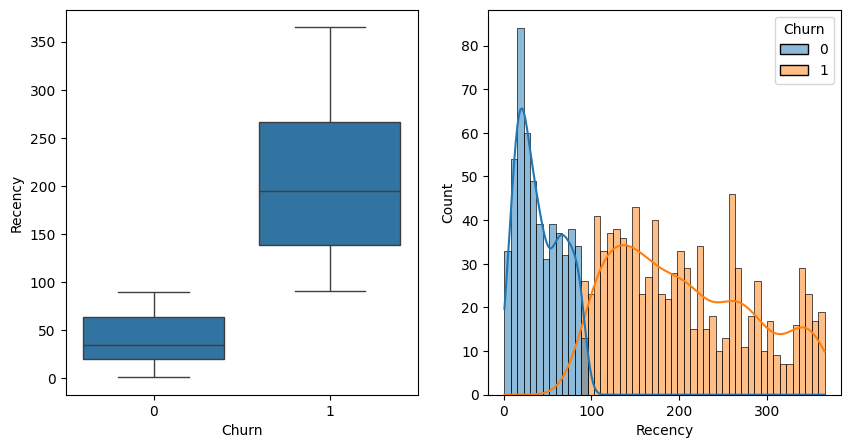

In [6]:
# VISUALIZATION
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='Recency', data=df)

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Recency', hue='Churn', bins=50, kde=True)

plt.show()

In [7]:
# SAVE TARGET FILE
df.to_csv('dataset_target.csv', index=False)

FEATURE ASSEMBLY

In [8]:
df_base = pd.read_csv('ml_features.csv')
df_target = pd.read_csv('dataset_target.csv')
df_cluster = pd.read_csv('DPMeans_Clustering_Results.csv')

print(df_base.shape, df_target.shape, df_cluster.shape)

(1468, 11) (1468, 12) (1468, 6)


In [9]:
# MERGE DATA
df = pd.merge(df_base, df_target[['CustomerID', 'Churn']], on='CustomerID')

df = pd.merge(df, df_cluster[['CustomerID', 'Cluster']], on='CustomerID', how='left')

print(df.shape)

(1468, 13)


In [10]:
# DATATYPE CLEANING
df['Cluster'] = df['Cluster'].astype('category')

numeric_cols = ['Recency', 'Frequency', 'Monetary', 'Coupon_Ratio',
                'Tenure_Months', 'Avg_Order_Value', 'Purchase_Interval',
                'Orders_last_30d', 'Spend_last_30d', 'Active_30d']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

CustomerID              int64
Recency                 int64
Frequency               int64
Monetary              float64
Coupon_Ratio          float64
Tenure_Months           int64
Avg_Order_Value       float64
Purchase_Interval     float64
Orders_last_30d       float64
Spend_last_30d        float64
Active_30d              int64
Churn                   int64
Cluster              category
dtype: object


In [11]:
# FINAL FEATURE LIST
final_columns = [
    'CustomerID',
    'Recency', 'Frequency', 'Monetary',
    'Coupon_Ratio',
    'Tenure_Months',
    'Avg_Order_Value',
    'Purchase_Interval',
    'Orders_last_30d',
    'Spend_last_30d',
    'Active_30d',
    'Cluster',
    'Churn'
]

df_final = df[final_columns].copy()

print(df_final.shape)

(1468, 13)


In [12]:
# SAVE FEATURE FILE
with open('final_features.pkl', 'wb') as f:
    pickle.dump(df_final, f)

df_final.to_csv('final_features.csv', index=False)

TRAIN TEST SPLIT

In [13]:

X = df_final.drop(['CustomerID', 'Churn'], axis=1)
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1174, 11) (294, 11)


In [14]:
# ENCODING
# LightGBM version
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

le = LabelEncoder()
X_train_lgb['Cluster'] = le.fit_transform(X_train_lgb['Cluster'])
X_test_lgb['Cluster'] = le.transform(X_test_lgb['Cluster'])

# CatBoost version
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

X_train_cat['Cluster'] = X_train_cat['Cluster'].astype('category')
X_test_cat['Cluster'] = X_test_cat['Cluster'].astype('category')

In [15]:
# SMOTE
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_lgb, y_train)

print("Before:", y_train.value_counts())
print("After :", pd.Series(y_train_res).value_counts())

Before: Churn
1    740
0    434
Name: count, dtype: int64
After : Churn
0    740
1    740
Name: count, dtype: int64


In [16]:
# SAVE AS CSV (easy to use later)

import os
os.makedirs("data/processed", exist_ok=True)

X_train_res.to_csv("data/processed/X_train.csv", index=False)
pd.Series(y_train_res).to_csv("data/processed/y_train.csv", index=False)

X_test_lgb.to_csv("data/processed/X_test.csv", index=False)
pd.Series(y_test).to_csv("data/processed/y_test.csv", index=False)

print("Saved CSV successfully")

Saved CSV successfully
